# Orchestrating workflows with LangGraph

In the [recipe on agents](14-agents.ipynb), `create_agent()` handed the model a set of tools and let it decide what to do, turn after turn, until the task was done. That autonomy is the point of an agent: we do not script the steps, the model picks them.

Sometimes we want the opposite. We know the steps in advance, and we want a request to follow a fixed path: classify it first, then send a summary request to one place and a citation request to another. For that we reach for an explicit graph. LangGraph, the framework named in the previous recipe's "Looking Ahead" section, lets us lay out the path ourselves and hand control to the model only where we choose.

In this recipe we build a **routing workflow**: a graph that reads a request, classifies what kind of help it needs, and routes it to a specialized step.

In [1]:
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv())

True

## What is a graph?

A **graph** is a way to model a process as a set of **states** connected by **transitions**. The states are the situations the process can be in, drawn as nodes, and the transitions are the moves between them, drawn as arrows from one state to the next.

Plenty of everyday things fit this shape:

- A **subway map**: each station is a state, each track between two stations is a transition.
- A **board game**: each square is a state, and a roll of the dice transitions you to another square.
- An **online checkout**: *browsing* → *cart* → *payment* → *confirmation*, where each step unlocks the next.

Here is the checkout flow drawn as a graph. Each box is a state; each arrow is an allowed transition. Notice the branch at *payment*: a successful payment moves forward to *confirmation*, while a failure loops back to *cart*.

```{mermaid}
flowchart LR
    START([start]) --> browsing[browsing]
    browsing --> cart[cart]
    cart --> payment[payment]
    payment -->|success| confirmation[confirmation]
    payment -->|failure| cart
    confirmation --> END([end])
```

The value of the graph view is that it separates two questions: *what are the possible states?* and *which transitions are allowed between them?* Once a process is drawn this way, the path through it becomes explicit. We can point at where it branches, where it loops back, and where it ends.

## From a graph to an agentic workflow

LangGraph uses this same vocabulary to lay out the steps an application takes. The mapping is direct:

- A **node** is a step of work, a plain Python function that does something (call a model, run a tool, transform data).
- An **edge** is a transition that says which step runs next. A fixed edge always leads to the same place; a **conditional** edge chooses the next step based on what has happened so far.
- The data the process carries from step to step is the **state**: a shared dictionary that every node reads from and writes back to.

A workflow runs by entering at a `START` point, following the edges from node to node while updating the state, and finishing at an `END` point.

```{note}
A [chain](08-building-chains.ipynb) runs its steps in a straight line. A graph can branch and even loop, so we reach for one when the path depends on the data rather than being fixed up front.
```

## Defining the state

Our example workflow to triage a request carries three pieces of data: the original `input`, the routing `decision` the classifier makes, and the final `output`. We declare that shape as a `TypedDict`:

In [2]:
from typing_extensions import TypedDict


class State(TypedDict):
    input: str  # the user's request
    decision: str  # which branch the router picked
    output: str  # the specialized node's result

```{note}
A [`TypedDict`](https://docs.python.org/3/library/typing.html#typing.TypedDict) is a regular Python dictionary with a declared shape: it lists the keys and the type of each value, so tools and readers know what to expect. The state is still an ordinary `dict` at runtime. As with the schemas in the [structured output recipe](15-structured-output.ipynb), this is not the only option, we could also describe the state with a [Pydantic](https://docs.pydantic.dev/) model or a [dataclass](https://docs.python.org/3/library/dataclasses.html). We use a `TypedDict` here because it is the lightest way to pin down the shape.
```

## The router node

The router decides which branch a request belongs to. We reuse the [structured output](15-structured-output.ipynb) idea: instead of parsing free text, we ask the model to fill a schema. As in that recipe, we define the schema as a [dataclass](https://docs.python.org/3/library/dataclasses.html); its one field is a `Literal` listing the allowed branches, so the model has to return one of those exact values.

In [3]:
from dataclasses import dataclass
from typing import Literal
from langchain_dartmouth.llms import ChatDartmouth

llm = ChatDartmouth(model_name="openai.gpt-oss-120b", temperature=0.0)


@dataclass
class Route:
    """The kind of help the user is asking for."""

    # The branch to handle the request: 'summarize', 'explain', or 'references'
    step: Literal["summarize", "explain", "references"]


# with_structured_output forces the model to fill in a valid Route
router = llm.with_structured_output(Route)

With the classifier ready, we write the router node. It reads the request from state, asks the classifier which branch fits, and writes that choice into `decision`.

In [4]:
from langchain_core.messages import HumanMessage, SystemMessage


def router_node(state: State):
    # Classify the request into one of the three branches
    decision = router.invoke(
        [
            SystemMessage(
                content=(
                    "You are a router. Set the 'step' field to one of: "
                    "'summarize' (condense given text), 'explain' (explain a "
                    "concept simply), or 'references' (suggest reading)."
                )
            ),
            HumanMessage(content=state["input"]),
        ]
    )
    # Write the decision back into shared state
    return {"decision": decision["step"]}

## The specialized nodes

Each branch is its own node. We keep them small: a research assistant that can summarize a passage, explain a concept in plain language, or suggest foundational reading. Each node reads `input`, calls the model with a branch-specific prompt, and writes the result to `output`.

In [5]:
def summarize_node(state: State):
    # Condense the input into a couple of sentences
    result = llm.invoke(f"Summarize this in two sentences:\n\n{state['input']}")
    return {"output": result.content}


def explain_node(state: State):
    # Re-explain the input for a newcomer
    result = llm.invoke(
        f"Explain this to a beginner in plain language:\n\n{state['input']}"
    )
    return {"output": result.content}


def references_node(state: State):
    # Suggest a short reading list for the topic
    result = llm.invoke(
        f"List three foundational references for this topic:\n\n{state['input']}"
    )
    return {"output": result.content}

## Wiring the graph

Now we connect the pieces. We add every node, send `START` into the router, and attach a **conditional edge** from the router. The conditional edge calls a small function that reads `decision` from state and returns the name of the branch to run. The mapping then translates that name into the node to visit. Each branch flows to `END`.

In [6]:
from langgraph.graph import StateGraph, START, END


def route_decision(state: State):
    # The conditional edge uses the router's decision to pick the next node
    return state["decision"]


builder = StateGraph(State)

# Register every node
builder.add_node("router_node", router_node)
builder.add_node("summarize", summarize_node)
builder.add_node("explain", explain_node)
builder.add_node("references", references_node)

# Start at the router, then branch on its decision
builder.add_edge(START, "router_node")
builder.add_conditional_edges(
    "router_node",
    route_decision,
    {  # value returned by route_decision -> node to run
        "summarize": "summarize",
        "explain": "explain",
        "references": "references",
    },
)

# Every branch ends the workflow
builder.add_edge("summarize", END)
builder.add_edge("explain", END)
builder.add_edge("references", END)

graph = builder.compile()

## Visualizing the graph

A compiled graph can draw itself, turning the nodes and edges back into the kind of states-and-transitions diagram we started with. The picture shows the branch structure at a glance: the router fans out to three nodes, each of which leads to the end.

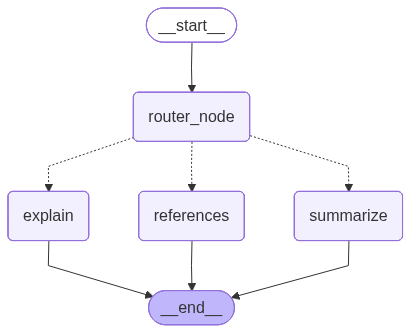

In [7]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

```{note}
`draw_mermaid_png()` sends the diagram to a remote renderer to turn it into an image. If you are offline or that service is unavailable, `print(graph.get_graph().draw_mermaid())` prints the same diagram as Mermaid text.
```

## Running the workflow

Let's send a request and see how the graph routes it. We invoke the graph with the initial state and read back the decision the router made and the output the branch produced.

In [8]:
request = "Can you give me a plain-language explanation of what attention is in a transformer?"

# The initial state is just the input, the rest is unset. We can conveniently omit any undefined parts of the state.
initial_state = {"input": request}

result = graph.invoke(initial_state)

When the graph is invoked, the entire workflow runs until it hits the `END` node. The result is the updated state:

In [9]:
print(f"DECISION: {result['decision']}")
print(f"OUTPUT:\n{result['output']}")

DECISION: explain
OUTPUT:
**What “attention” means in a transformer – explained in everyday language**

---

### 1. The problem a transformer tries to solve  

When a computer reads a sentence like  

> *“The cat that chased the mouse was tired.”*  

it has to understand how each word relates to the others.  
The word **“cat”** is the animal that **“was tired.”**  
The word **“mouse”** is the thing being chased.  

A traditional model would look at the words one after another, like reading a book from left to right.  
A transformer, instead, lets every word look at **all** the other words at the same time and decide which ones are most important for its own meaning. That “deciding which other words to look at” is what we call **attention**.

---

### 2. A simple everyday analogy  

**Imagine a group discussion.**  
Everyone in the room has a piece of paper with a word on it.  
When it’s your turn to speak, you don’t just shout out your word; you first **listen** to the other people and

With our current setup, the graph's state is not retained between invocations. We therefore don't have to explicitly reset the state or worry about carrying over any results from previous runs.

```{note}
Managing the graph's state can become the most challenging part of a workflow. LangGraph has extensive options to give your graph short-term or long-term memory, share state between graphs, pause and resume graph execution, restore previous checkpoints, and more. You can learn more about these advanced capabilities in [the official LangGraph documentation](https://docs.langchain.com/oss/python/langgraph).
```

Now let's send two more requests that should get routed differently:

In [10]:
requests = [
    (
        "Summarize this abstract: We introduce a retrieval-augmented generation "
        "method that retrieves passages from a corpus and conditions the generator "
        "on them, improving factual accuracy on open-domain question answering "
        "while keeping the model size fixed."
    ),
    "What are the foundational papers I should read about reinforcement learning from human feedback?",
]

for request in requests:
    result = graph.invoke({"input": request})
    print(f"DECISION: {result['decision']}")
    print(f"OUTPUT:\n{result['output']}")
    print("\n" + "-" * 60 + "\n")

DECISION: summarize
OUTPUT:
The paper presents a retrieval‑augmented generation approach that first pulls relevant passages from a large corpus and then conditions a fixed‑size language model on those texts. This method markedly improves factual accuracy in open‑domain question answering while keeping the model’s size unchanged.

------------------------------------------------------------

DECISION: references
OUTPUT:
Below are three papers that are widely regarded as the “foundational” works that introduced, formalized, and popularized **Reinforcement Learning from Human Feedback (RLHF)**.  Reading them in order will give you a clear picture of how the idea evolved—from the first proof‑of‑concept on simple control tasks to the large‑scale language‑model pipelines used today.

| # | Reference | Why it’s foundational | Link |
|---|-----------|----------------------|------|
| 1 | **Christiano, P., Leike, J., Brown, T. B., Martic, M., Legg, S., & Amodei, D. (2017). *Deep Reinforcement Le

Each request landed in the branch we would expect, and only that branch ran. The router read the intent, and the conditional edge sent the work to the matching node.

```{warning}
Please note that in the above example, we are committing an LLM design crime: We should never ask an LLM for citations without also attaching a knowledge base for it to refer to. When relying purely on its pre-training, the risk of hallucinated citations is too high. So don't be surprised if the above citation is flawed! In a real application, we would do better.
```

## Workflows or agents?

This routing graph and the agent from the previous recipe solve different problems.

```{hint}
Reach for a **workflow** when you know the paths in advance and want the same request to take the same route every time, like classifying a ticket and dispatching it. Reach for an **agent** when the path is open-ended and you want the model to choose its own steps. The [next recipe](17-multi-agent.ipynb) combines the two: it places whole agents inside a graph so several of them can coordinate.
```

## Summary

In this recipe, we have learned how to orchestrate a multi-step workflow with an explicit LangGraph graph:

- A LangGraph workflow is built from **state** (a shared dictionary), **nodes** (functions that read and update state), and **edges** (which decide what runs next).
- **`add_conditional_edges`** branches the graph by calling a function that inspects state and names the next node.
- A **structured-output classifier** makes a reliable router: a `Literal` schema constrains the model to one of the allowed branches.
- Use a **workflow** when the paths are known in advance, and an **agent** when the model should choose its own path.